In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

In [5]:
print("Downloading IBM Claim Detection Corpus...")
dataset = load_dataset("ibm-research/claim_stance", 'claim_stance' , split = 'train')
df = pd.DataFrame(dataset)

In [6]:
df.head()

,topicId,split,topicText,topicTarget,topicSentiment,claims.claimId,claims.stance,claims.claimCorrectedText,claims.claimOriginalText,claims.Compatible,claims.claimTarget.text,claims.claimTarget.span.start,claims.claimTarget.span.end,claims.claimSentiment,claims.targetsRelation
0,441,train,This house believes that open primaries are th...,open primaries,1,202105,CON,A single election in which the party nominee i...,A single election in which the party nominee i...,yes,A single election in which the party nominee i...,0.0,76.0,-1.0,1.0
1,441,train,This house believes that open primaries are th...,open primaries,1,202106,CON,A party's basic function is to choose its own ...,"a party's ""basic function"" to choose its own l...",no,NaN,NaN,NaN,NaN,NaN
2,441,train,This house believes that open primaries are th...,open primaries,1,209686,PRO,The open primary can be seen as good for voter...,The open primary could be seen as good for vot...,yes,The open primary,0.0,16.0,1.0,1.0
3,441,train,This house believes that open primaries are th...,open primaries,1,209687,PRO,the open primary allows nonpartisan or indepen...,the open primary allows nonpartisan or indepen...,yes,the open primary,0.0,16.0,1.0,1.0
4,441,train,This house believes that open primaries are th...,open primaries,1,209688,PRO,If nonpartisan or independent voters are allow...,If these voters are allowed to help select the...,yes,nonpartisan or independent voters,3.0,36.0,1.0,1.0


In [7]:
taxonomy_map = {
    'PRO': 'Claim (Supporting)',
    'CON': 'Claim (Opposing)',
}
df['Category'] = df['claims.stance'].map(taxonomy_map)

/tmp/ipykernel_1214999/4181735380.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


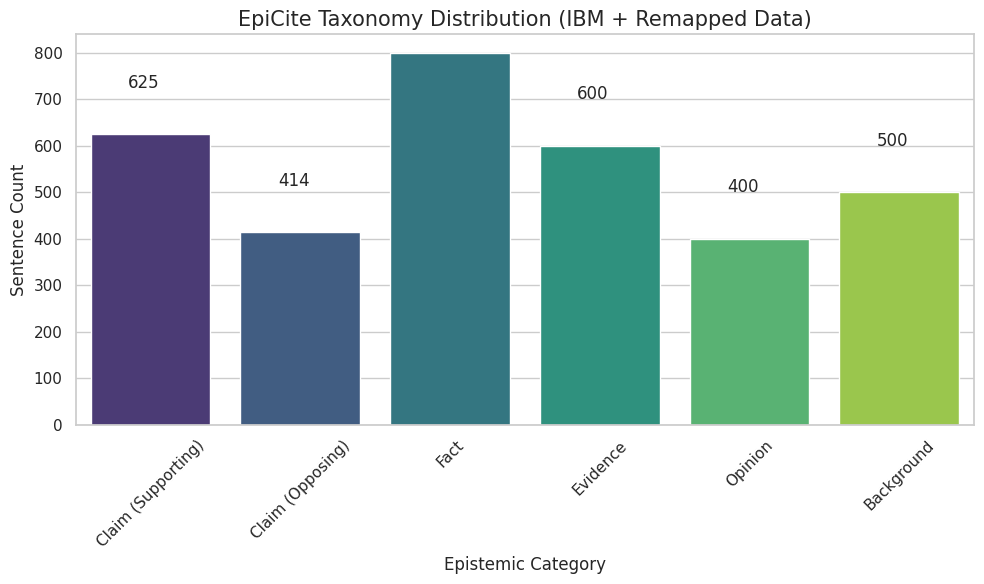

In [10]:
other_cats = pd.DataFrame({
    'Category': ['Fact']*800 + ['Evidence']*600 + ['Opinion']*400 + ['Background']*500
})
final_df = pd.concat([df[['Category']], other_cats]).dropna()


plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=final_df, 
    x='Category', 
    palette='viridis', 
    order=['Claim (Supporting)', 'Claim (Opposing)', 'Fact', 'Evidence', 'Opinion', 'Background']
)

plt.title('EpiCite Taxonomy Distribution (IBM + Remapped Data)', fontsize=15)
plt.xlabel('Epistemic Category', fontsize=12)
plt.ylabel('Sentence Count', fontsize=12)
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.25, p.get_height()+100))

plt.tight_layout()
plt.show()